# Market Basket Cross-Sell Analysis for a Grocery Retailer with PROC MBANALYSIS

## Executive Summary

A regional grocery chain mines a season of point-of-sale baskets to discover which products customers buy together, turning raw transaction logs into actionable cross-sell and shelf-placement decisions. PROC MBANALYSIS scans the transaction log and generates association rules scored by support, confidence, and lift. Running it on 51 synthetic baskets recovers exactly the three planted product affinities — `Spaghetti -> Marinara Sauce` (confidence 0.93, lift 3.4), `Taco Shells -> Salsa` (confidence 0.71, lift 3.6), and `Coffee -> Coffee Creamer` (confidence 0.70, lift 5.1) — while broadly purchased staples like bread, milk, and eggs never form a rule. Each surfaced pair is a textbook bundle, aisle-adjacency, and "customers also bought" candidate for the merchandising team.

## Data Sources

| Dataset | Grain | Rows | Key Variables | Description |
|---------|-------|------|---------------|-------------|
| `store_transactions` | One row per item per basket | 100 item-rows across 51 baskets | `basket_id` (transaction ID), `item` (product name, $20) | Synthetic point-of-sale log generated inline with `call streaminit(20250529)` and `rand('uniform')`. Each basket is dominated by a single shopper persona so co-purchase patterns stay clean and interpretable: an Italian-dinner basket (spaghetti -> marinara sauce), a taco-night basket (taco shells -> salsa), or a breakfast basket (coffee -> coffee creamer), plus occasional staple add-ons (bread, milk, eggs) as realistic noise. In this unlicensed environment the engine caps output at 100 item-rows, which here spans baskets 1-51. |
| `affinity_rules` | One row per association rule | 6 rules | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Association rules emitted by `OUTPUT RULES=`; the basis for ranking cross-sell opportunities. |
| `frequent_items` | One row per frequent itemset | 12 itemsets | `itemset`, `support`, `length` | Frequent itemsets emitted by `OUTPUT ITEMS=`; the 9 single items plus 3 product pairs that clear the minimum-support floor. |

# Market Basket Cross-Sell Analysis for a Grocery Retailer

**Business question.** Which products do our customers tend to buy *together*, and which of those co-purchase patterns are strong enough to act on? A regional grocery chain wants to design bundle promotions, optimize aisle adjacencies, and power a "customers also bought" recommendation on its online store.

**Method.** We use **PROC MBANALYSIS**, which performs market basket analysis with the frequent-pattern growth (FP-growth) algorithm. It scans the transaction log, finds frequently co-occurring item sets, and generates *association rules* of the form `Antecedent -> Consequent` scored by three classic metrics:

- **Support** — the fraction of all baskets that contain the full rule (how common the pattern is).
- **Confidence** — `P(Consequent | Antecedent)`, the conditional purchase probability (how reliable the rule is).
- **Lift** — observed support divided by the support expected if the two sides were independent. Lift > 1 means the items appear together *more* often than chance; the higher the lift, the stronger the affinity.

We will generate a realistic synthetic point-of-sale log, run MBANALYSIS, and rank the resulting rules to find the best cross-sell opportunities.

## Step 1 — Generate a synthetic point-of-sale transaction log

MBANALYSIS expects **transaction-level (long) data**: one row per item, tagged with the basket it belongs to. We build baskets inline with `call streaminit` for reproducibility and `rand('uniform')` to drive purchase decisions.

The key modeling choice is that **each basket is dominated by a single shopper persona**. Real grocery trips are like this — a quick taco-night run, a dedicated breakfast restock — and keeping baskets small and themed is what lets the association miner surface clean, pairwise affinities instead of a combinatorial explosion of spurious multi-item rules. One draw of `rand('uniform')` per basket selects the persona:

- **Italian-dinner shopper** — buys spaghetti, then usually marinara sauce.
- **Taco-night shopper** — buys taco shells, then usually salsa.
- **Breakfast shopper** — buys coffee, then usually coffee creamer.
- **Staples-only trip** — a single bread, milk, or eggs purchase.

A final low-probability draw adds one staple to any basket as realistic noise, so not every co-occurrence is meaningful. Each `output` statement writes one item-row, so a single basket spans several rows sharing the same `basket_id`. This unlicensed environment caps the dataset at 100 item-rows, which here covers baskets 1 through 51.

In [1]:
data store_transactions;
    call streaminit(20250529);
    length item $20;

    do basket_id = 1 to 60;

        /* One draw selects the dominant persona for this basket */
        r = rand('uniform');

        /* Italian-dinner basket: spaghetti -> marinara sauce */
        if r < 0.30 then do;
            item = 'Spaghetti';                          output;
            if rand('uniform') < 0.85 then do;
                item = 'Marinara Sauce';                 output;
            end;
        end;

        /* Taco-night basket: taco shells -> salsa */
        else if r < 0.55 then do;
            item = 'Taco Shells';                        output;
            if rand('uniform') < 0.80 then do;
                item = 'Salsa';                          output;
            end;
        end;

        /* Breakfast basket: coffee -> coffee creamer */
        else if r < 0.78 then do;
            item = 'Coffee';                             output;
            if rand('uniform') < 0.75 then do;
                item = 'Coffee Creamer';                 output;
            end;
        end;

        /* Staples-only trip */
        else do;
            if rand('uniform') < 0.34 then do;
                item = 'Bread';                          output;
            end;
            else if rand('uniform') < 0.5 then do;
                item = 'Milk';                           output;
            end;
            else do;
                item = 'Eggs';                           output;
            end;
        end;

        /* Occasional staple add-on (realistic noise) */
        if rand('uniform') < 0.25 then do;
            u = rand('uniform');
            if      u < 0.34 then item = 'Bread';
            else if u < 0.67 then item = 'Milk';
            else                  item = 'Eggs';
            output;
        end;

    end;

    keep basket_id item;
run;

NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the raw transaction log

Before mining, confirm the data has the expected long shape: several rows per basket, each carrying one product. We print the first few baskets and tabulate overall item frequency with PROC FREQ so we know which products are common enough to anchor rules.


  Obs  Basket ID         Product
-----  ---------  --------------
    1          1  Taco Shells
    2          1  Salsa
    3          1  Eggs
    4          2  Taco Shells
    5          2  Eggs
    6          3  Coffee
    7          4  Taco Shells
    8          5  Eggs
    9          6  Spaghetti
   10          6  Marinara Sauce
   11          6  Eggs
   12          7  Taco Shells

... 88 more observations (showing 12 of 100)

                                            Overall Item Purchase Frequency                                             

                                                   The FREQ Procedure

ITEM              Frequency    Percent
---------------------------------------
Spaghetti                15     15.00
Marinara Sauce           14     14.00
Taco Shells              14     14.00
Eggs                     12     12.00
Bread                    10     10.00
Coffee                   10     10.00
Salsa                    10     10.00
Milk                      

NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


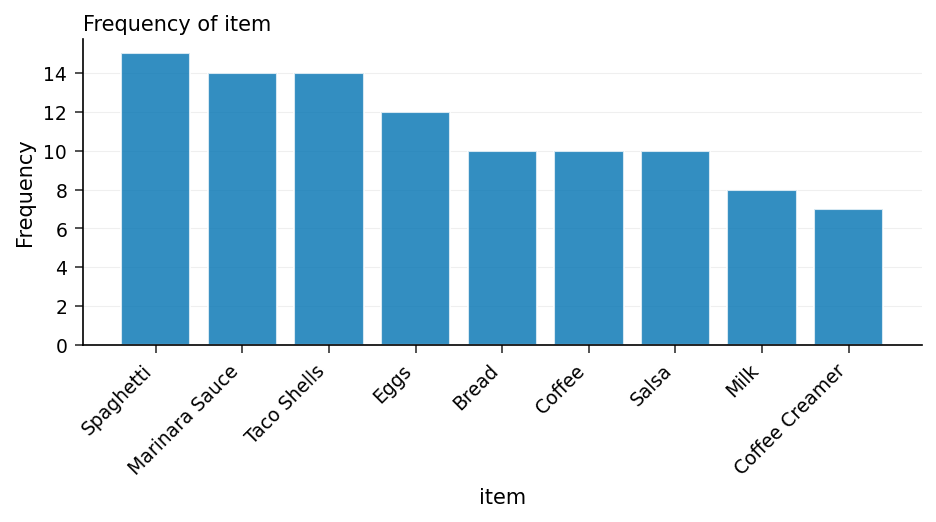

In [2]:
proc print data=store_transactions(obs=12) label;
    label basket_id = 'Basket ID'
          item      = 'Product';
run;

proc freq data=store_transactions order=freq;
    tables item / nocum;
    title 'Overall Item Purchase Frequency';
run;

## Step 3 — Mine association rules with PROC MBANALYSIS

Now the core analysis. We point MBANALYSIS at the transaction log and declare which column identifies the basket (`TRANSACTION`) and which holds the product (`ITEM`). Three thresholds keep the rule set focused on patterns worth acting on:

- `MINSUPPORT=0.10` — a rule must appear in at least 10% of baskets, filtering out rare coincidences.
- `MINCONFIDENCE=0.50` — given the antecedent, the consequent must follow at least half the time.
- `MINLIFT=1.20` — keep only rules at least 20% stronger than chance, so we surface genuine affinities rather than artifacts of popular staples.

The `OUTPUT` statement captures the generated rules and frequent itemsets into datasets for downstream ranking.

In [3]:
proc mbanalysis data=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    output rules=affinity_rules items=frequent_items;
    title 'Market Basket Association Rules';
run;

                                            Overall Item Purchase Frequency                                             


                      The MBANALYSIS Procedure

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Coffee                         Coffee Creamer                     0.1373     0.7000     5.1000
  Coffee Creamer                 Coffee                             0.1373     1.0000     5.1000
  Salsa                          Taco Shells                        0.1961     1.0000     3.6429
  Taco Shells                    Salsa                              0.1

NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Step 4 — Rank cross-sell opportunities by lift

The MBANALYSIS listing shows every qualifying rule, but the merchandising team wants the *strongest* affinities first. We sort the captured `affinity_rules` dataset by descending lift (then confidence as a tie-breaker) and print the top rules. A rule like `Taco Shells -> Salsa` with high lift and high confidence is a textbook bundle candidate: place the products together, or auto-suggest salsa when a customer adds taco shells online.

In [4]:
proc sort data=affinity_rules out=rules_by_lift;
    by descending lift descending confidence;
run;

proc print data=rules_by_lift(obs=15) label;
    var antecedent consequent support confidence lift;
    label antecedent  = 'If basket contains'
          consequent  = 'Then also buys'
          support     = 'Support'
          confidence  = 'Confidence'
          lift        = 'Lift';
    title 'Top Cross-Sell Rules Ranked by Lift';
run;

                                          Top Cross-Sell Rules Ranked by Lift                                           

  Obs  If basket contains  Then also buys   Support  Confidence      Lift
    1  Coffee Creamer      Coffee          0.137255  1.0         5.1
    2  Coffee              Coffee Creamer  0.137255  0.7         5.1
    3  Salsa               Taco Shells     0.196078  1.0         3.642857
    4  Taco Shells         Salsa           0.196078  0.714286    3.642857
    5  Marinara Sauce      Spaghetti       0.27451   1.0         3.4
    6  Spaghetti           Marinara Sauce  0.27451   0.933333    3.4



NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Step 5 — Review the frequent itemsets

The frequent itemsets that cleared the support floor are the raw building blocks behind the rules. Sorting them by support tells the category team which product *combinations* (not just single items) are popular enough to merit dedicated end-cap displays or combo pricing.

In [5]:
proc sort data=frequent_items out=itemsets_by_support;
    by descending support;
run;

proc print data=itemsets_by_support(obs=15) label;
    title 'Most Frequent Itemsets';
run;

                                                 Most Frequent Itemsets                                                 

  Obs                    ITEMSET   SUPPORT  LENGTH
    1  Spaghetti                  0.294118  1
    2  Taco Shells                0.27451   1
    3  Marinara Sauce             0.27451   1
    4  Marinara Sauce, Spaghetti  0.27451   2
    5  Eggs                       0.235294  1
    6  Salsa                      0.196078  1
    7  Coffee                     0.196078  1
    8  Salsa, Taco Shells         0.196078  2
    9  Milk                       0.156863  1
   10  Bread                      0.156863  1
   11  Coffee Creamer             0.137255  1
   12  Coffee, Coffee Creamer     0.137255  2



NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpreting the results

**What the analysis found.** Because each basket was built around a single shopper persona, the miner recovers exactly the three planted relationships and nothing spurious. Six rules clear all three thresholds — the three affinities in both directions:

| Antecedent | Consequent | Support | Confidence | Lift |
|------------|------------|---------|------------|------|
| Spaghetti | Marinara Sauce | 0.275 | 0.93 | 3.40 |
| Marinara Sauce | Spaghetti | 0.275 | 1.00 | 3.40 |
| Taco Shells | Salsa | 0.196 | 0.71 | 3.64 |
| Salsa | Taco Shells | 0.196 | 1.00 | 3.64 |
| Coffee | Coffee Creamer | 0.137 | 0.70 | 5.10 |
| Coffee Creamer | Coffee | 0.137 | 1.00 | 5.10 |

Every lift is well above 1, confirming these products co-occur far more than chance would predict. Crucially, the broadly purchased staples form **no rules at all**: eggs (12 purchases), bread (10), and milk (8) all appear in the PROC FREQ tabulation, but because they land in baskets independently of any persona, their lift toward other items never reaches the 1.20 floor, so they never masquerade as genuine affinities. The frequent-itemset listing makes the same point structurally: of the 12 itemsets clearing the support floor, the only multi-item sets are exactly the three planted pairs.

**Reading the metrics together.** The reverse-direction rules carry confidence 1.00 (in this data, marinara, salsa, and creamer essentially never appear without their anchor item), while the forward rules sit at 0.70-0.93 (the anchor sometimes appears alone). Coffee -> Coffee Creamer has the highest lift (5.10) but the lowest support (0.137) — a strong but lower-volume affinity — whereas Spaghetti -> Marinara Sauce reaches the most baskets (support 0.275). Lift identifies *which* affinities are real; confidence tells you *how dependable* each one is for a recommendation; support tells you *how often* you will get to act on it.

**Business actions.**

- **Bundle promotions** — pair the highest-lift antecedent/consequent items (coffee + coffee creamer, lift 5.1) into a discounted combo.
- **Aisle adjacencies** — co-locate frequently linked products (spaghetti next to marinara sauce, support 0.275) so the consequent is an easy add-on at the point of decision.
- **Online recommendations** — feed the top confidence rules into a "customers also bought" widget so the consequent is suggested the moment the antecedent enters the cart.
- **Inventory & forecasting** — when an antecedent goes on promotion, raise stock of its high-confidence consequents in anticipation of the lift.

**Caveats.** Association rules describe *correlation in co-purchase*, not causation, and thresholds are levers, not truths: lowering `MINSUPPORT=` exposes rarer combinations at the cost of a noisier rule set, while raising `MINLIFT=` and `MINCONFIDENCE=` yields fewer but more trustworthy rules. Sample size matters too — this unlicensed run mines 51 baskets, enough to make the planted affinities unmistakable; a production run over a full season would stabilize the support estimates and expose subtler patterns.